In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA3'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import tempfile
from pathlib import Path

# Dossier temporaire portable (Windows / macOS / Linux / Colab)
TMP = Path(tempfile.gettempdir())

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


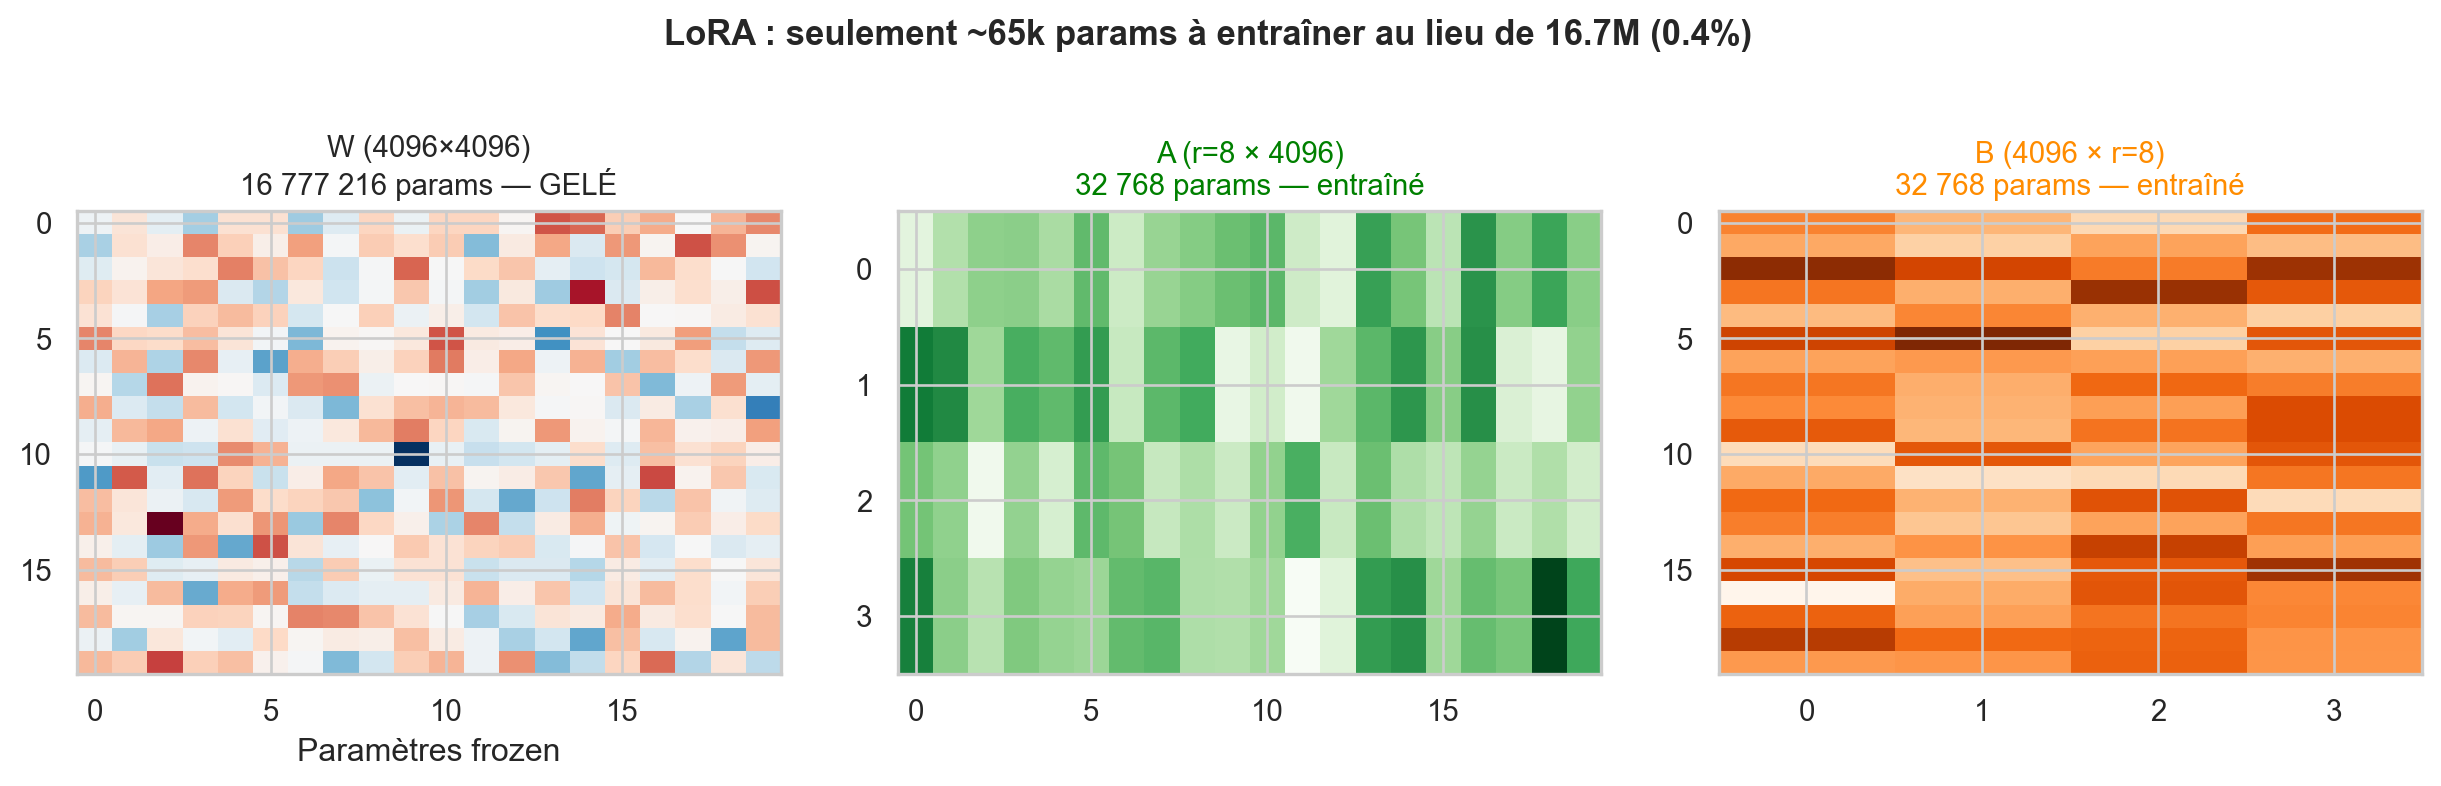

In [3]:
#| label: fig-lora
#| fig-cap: 'LoRA : décomposition en matrices de rang faible'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Matrice originale (figée)
axes[0].imshow(np.random.randn(20, 20), cmap="RdBu", aspect="auto")
axes[0].set_title("W (4096×4096)\n16 777 216 params — GELÉ", fontsize=11)
axes[0].set_xlabel("Paramètres frozen")

# Matrice A (entraînée)
axes[1].imshow(np.random.randn(4, 20), cmap="Greens", aspect="auto")
axes[1].set_title("A (r=8 × 4096)\n32 768 params — entraîné", fontsize=11, color="green")

# Matrice B
axes[2].imshow(np.random.randn(20, 4), cmap="Oranges", aspect="auto")
axes[2].set_title("B (4096 × r=8)\n32 768 params — entraîné", fontsize=11, color="darkorange")

plt.suptitle("LoRA : seulement ~65k params à entraîner au lieu de 16.7M (0.4%)",
              fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

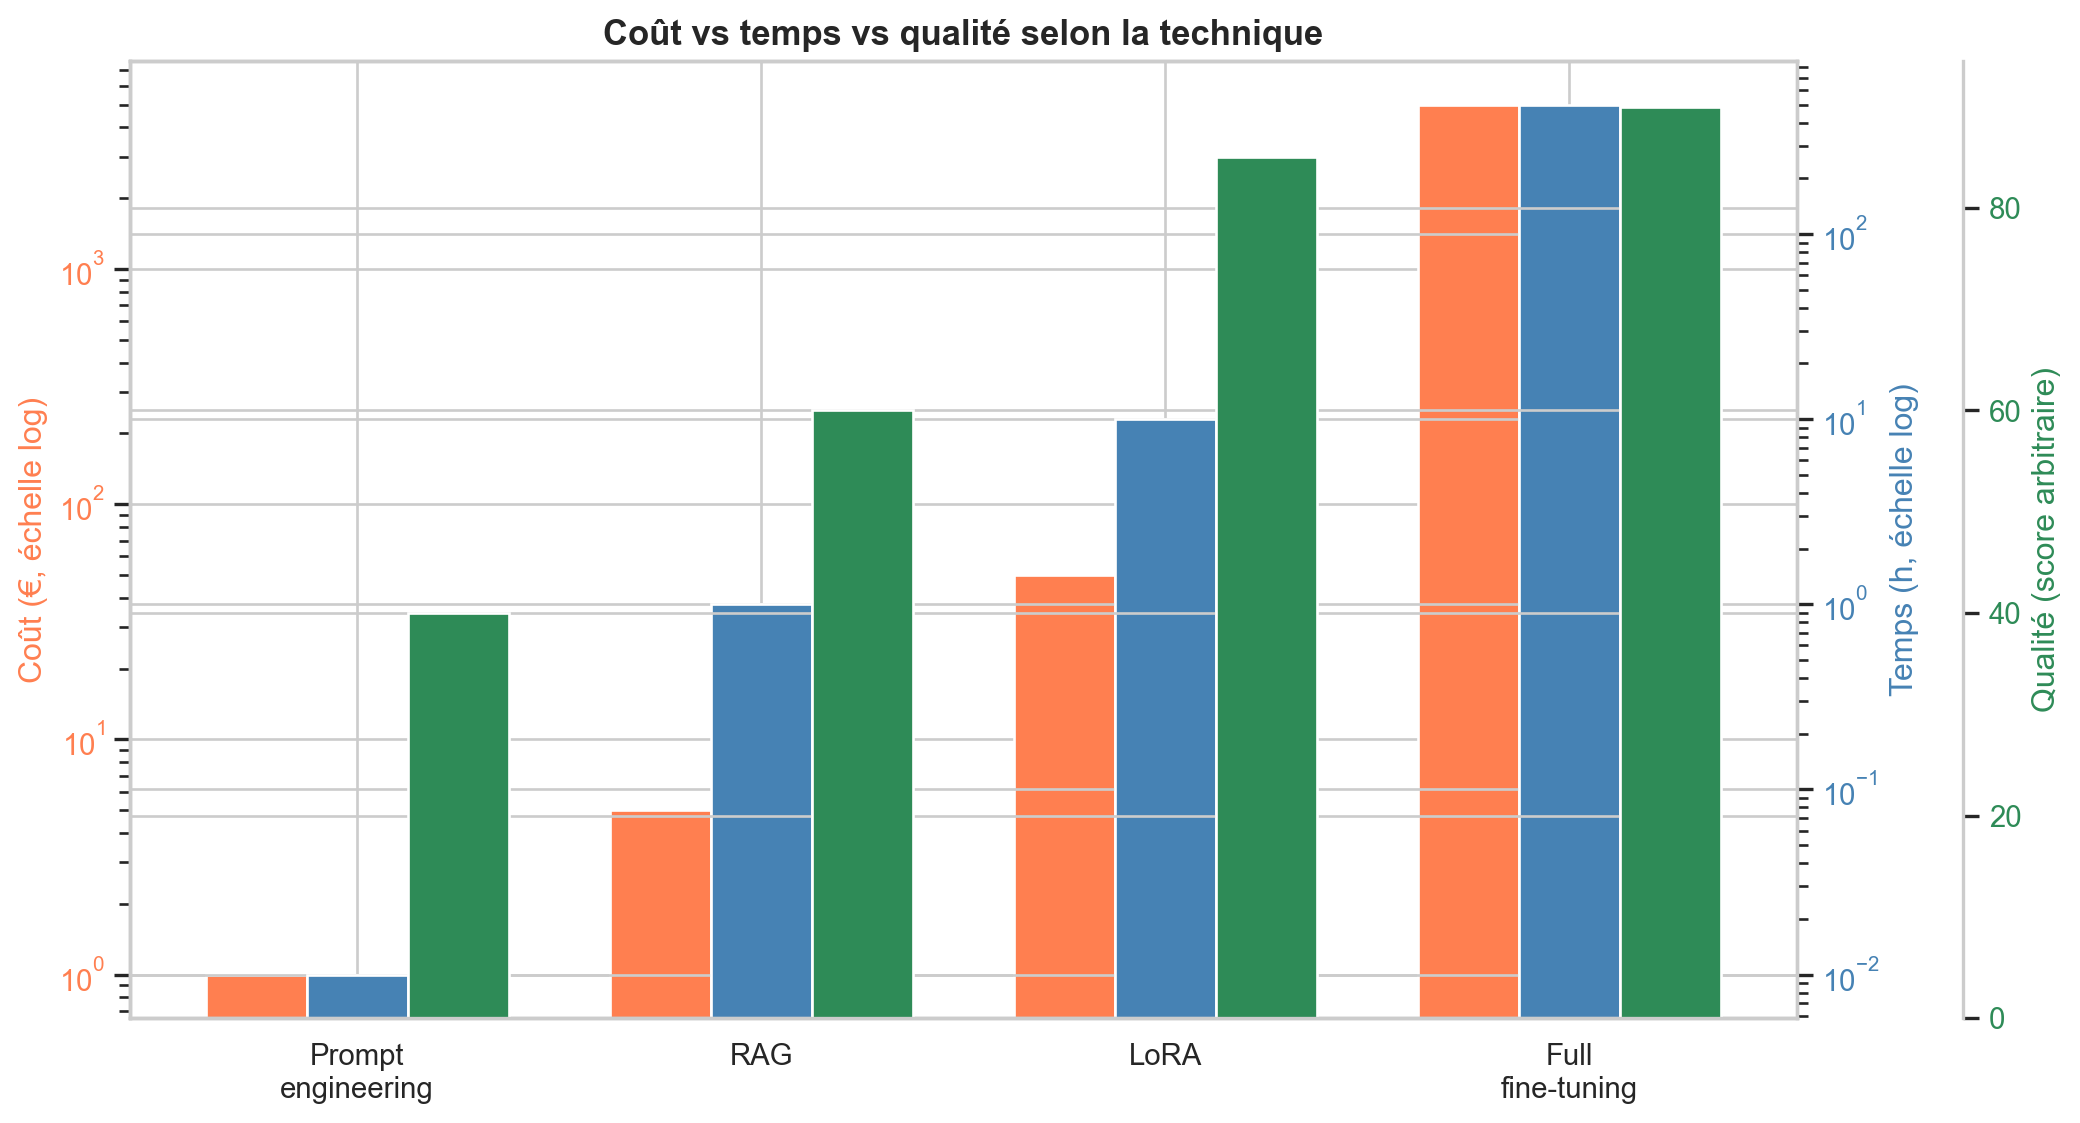

In [4]:
#| label: fig-comparaison-techniques
#| fig-cap: 'Comparaison : full fine-tuning vs LoRA vs prompt engineering'

techniques = ["Prompt\nengineering", "RAG", "LoRA", "Full\nfine-tuning"]
cout = [1, 5, 50, 5000]  # échelle arbitraire
temps = [0.01, 1, 10, 500]  # heures
qualite_spec = [40, 60, 85, 90]  # score arbitraire

fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(techniques))
w = 0.25

ax1.bar(x - w, cout, w, label="Coût (€, log)", color="coral")
ax1.set_yscale("log")
ax1.set_ylabel("Coût (€, échelle log)", color="coral")
ax1.set_xticks(x)
ax1.set_xticklabels(techniques)
ax1.tick_params(axis="y", labelcolor="coral")

ax2 = ax1.twinx()
ax2.bar(x, temps, w, label="Temps (h, log)", color="steelblue")
ax2.set_yscale("log")
ax2.set_ylabel("Temps (h, échelle log)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.1))
ax3.bar(x + w, qualite_spec, w, label="Qualité spécialisation", color="seagreen")
ax3.set_ylabel("Qualité (score arbitraire)", color="seagreen")
ax3.tick_params(axis="y", labelcolor="seagreen")

ax1.set_title("Coût vs temps vs qualité selon la technique", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
#| eval: false
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForCausalLM

# 1. Charger le modèle de base
modele = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B",  # petit modèle pour la démo
    torch_dtype="auto",
    device_map="auto",
)

# 2. Configuration LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # type de tâche
    r=8,                            # rang
    lora_alpha=16,                  # scaling factor
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],  # quelles couches LoRA-ifier
)

# 3. Wrapper le modèle
modele_lora = get_peft_model(modele, lora_config)

# 4. Voir le gain
modele_lora.print_trainable_parameters()
# trainable params: 851,968 || all params: 1,236,662,272 || trainable%: 0.069

In [6]:
# Dataset de fine-tuning TechVolt (synthétique)
dataset_techvolt = [
    {
        "instruction": "Le client signale que sa borne affiche E01. Réponds en format ticket.",
        "reponse": "TICKET-TECH\n-----------\nCode : E01\nDiagnostic : Surchauffe\nAction : Laisser refroidir 30 min\nUrgence : Normale"
    },
    {
        "instruction": "Le client signale que sa borne affiche E04. Réponds en format ticket.",
        "reponse": "TICKET-TECH\n-----------\nCode : E04\nDiagnostic : Court-circuit détecté\nAction : NE PAS UTILISER, contacter SAV immédiatement\nUrgence : CRITIQUE"
    },
    {
        "instruction": "Le client signale que sa borne affiche E02. Réponds en format ticket.",
        "reponse": "TICKET-TECH\n-----------\nCode : E02\nDiagnostic : Défaut de terre\nAction : Contacter un électricien certifié\nUrgence : Haute"
    },
    # ... imaginer 50+ exemples pour un vrai fine-tuning
]

# Sauvegarde en JSONL
chemin_dataset = TMP / "dataset_techvolt.jsonl"
with open(chemin_dataset, "w", encoding="utf-8") as f:
    for ex in dataset_techvolt:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

# Relire pour vérifier
with open(chemin_dataset, encoding="utf-8") as f:
    for ligne in f:
        ex = json.loads(ligne)
        print(f"Instruction : {ex['instruction'][:60]}")
        print(f"Réponse     : {ex['reponse'][:60]}...\n")

Instruction : Le client signale que sa borne affiche E01. Réponds en forma
Réponse     : TICKET-TECH
-----------
Code : E01
Diagnostic : Surchauffe
A...

Instruction : Le client signale que sa borne affiche E04. Réponds en forma
Réponse     : TICKET-TECH
-----------
Code : E04
Diagnostic : Court-circui...

Instruction : Le client signale que sa borne affiche E02. Réponds en forma
Réponse     : TICKET-TECH
-----------
Code : E02
Diagnostic : Défaut de te...



In [7]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(dataset_techvolt, test_size=0.2, random_state=42)

print(f"Train : {len(train)} exemples")
print(f"Val   : {len(val)} exemples")

Train : 2 exemples
Val   : 1 exemples


In [8]:
#| eval: false
from datasets import Dataset

# Charger depuis JSONL
ds = Dataset.from_json(str(TMP / "dataset_techvolt.jsonl"))

# Split
ds = ds.train_test_split(test_size=0.2, seed=42)
print(ds)
# DatasetDict({
#     train: Dataset({features: ['instruction', 'reponse'], num_rows: 2}),
#     test: Dataset({features: ['instruction', 'reponse'], num_rows: 1})
# })

In [9]:
avis_dataset = [
    # POSITIF
    {"avis": "Borne parfaite, installation rapide !", "classe": "POSITIF"},
    {"avis": "Je recommande à 100%, vraiment bien.", "classe": "POSITIF"},
    {"avis": "Très content de mon achat, ça marche nickel.", "classe": "POSITIF"},
    {"avis": "Qualité au rendez-vous, SAV réactif.", "classe": "POSITIF"},
    {"avis": "Super produit, je l'utilise tous les jours.", "classe": "POSITIF"},
    # NEUTRE
    {"avis": "Correct pour le prix.", "classe": "NEUTRE"},
    {"avis": "Fait le job, rien d'exceptionnel.", "classe": "NEUTRE"},
    {"avis": "Ça marche, pas de problème particulier.", "classe": "NEUTRE"},
    {"avis": "Produit standard, conforme à la description.", "classe": "NEUTRE"},
    {"avis": "Normal, comme attendu.", "classe": "NEUTRE"},
    # NEGATIF
    {"avis": "Panne au bout de 3 mois, inadmissible.", "classe": "NEGATIF"},
    {"avis": "SAV injoignable, je ne recommande pas.", "classe": "NEGATIF"},
    {"avis": "L'app plante, c'est pénible.", "classe": "NEGATIF"},
    {"avis": "Très déçu, pas à la hauteur.", "classe": "NEGATIF"},
    {"avis": "À éviter, problèmes récurrents.", "classe": "NEGATIF"},
]

# Sauvegarde
with open(TMP / "avis_techvolt.jsonl", "w", encoding="utf-8") as f:
    for ex in avis_dataset:
        f.write(json.dumps(ex, ensure_ascii=False) + "\n")

# Split
train, val = train_test_split(avis_dataset, test_size=0.2, random_state=42,
                                stratify=[e["classe"] for e in avis_dataset])

# Stats
def stats(data, nom):
    classes = pd.Series([e["classe"] for e in data]).value_counts()
    print(f"\n{nom} ({len(data)} exemples) :")
    print(classes.to_string())

stats(train, "Train")
stats(val, "Val")


Train (12 exemples) :
NEGATIF    4
NEUTRE     4
POSITIF    4

Val (3 exemples) :
NEGATIF    1
POSITIF    1
NEUTRE     1


In [10]:
#| eval: false
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

# 1. Charger tokenizer + modèle
model_name = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

modele = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto",
)

# 2. Préparer dataset
def format_prompt(example):
    """Formate un exemple pour le training."""
    return {
        "text": f"### Instruction:\n{example['instruction']}\n\n### Réponse:\n{example['reponse']}"
    }

ds = Dataset.from_json(str(TMP / "dataset_techvolt.jsonl"))
ds = ds.map(format_prompt)

# 3. Tokeniser
def tokenize(example):
    return tokenizer(example["text"], truncation=True, max_length=512, padding="max_length")

ds_tokenized = ds.map(tokenize, batched=True)

# 4. LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
)
modele_lora = get_peft_model(modele, lora_config)
modele_lora.print_trainable_parameters()

# 5. Training
training_args = TrainingArguments(
    output_dir="./techvolt_model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    learning_rate=3e-4,
    warmup_steps=10,
    logging_steps=5,
    save_strategy="epoch",
    fp16=True,
)

trainer = Trainer(
    model=modele_lora,
    args=training_args,
    train_dataset=ds_tokenized,
    tokenizer=tokenizer,
)

trainer.train()

# 6. Sauvegarder l'adapter LoRA
modele_lora.save_pretrained("./techvolt_adapter")

In [11]:
#| eval: false
from peft import PeftModel

# Modèle de base
modele_base = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B")

# Appliquer l'adapter LoRA
modele_final = PeftModel.from_pretrained(modele_base, "./techvolt_adapter")

# Inférence
inputs = tokenizer(
    "### Instruction:\nLe client signale E03. Réponds en format ticket.\n\n### Réponse:\n",
    return_tensors="pt"
)
outputs = modele_final.generate(**inputs, max_new_tokens=100)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

In [12]:
#| eval: false
def valider_format_ticket(sortie: str) -> bool:
    """Vérifie que le format TICKET-TECH est respecté."""
    required_fields = ["TICKET-TECH", "Code :", "Diagnostic :", "Action :", "Urgence :"]
    return all(f in sortie for f in required_fields)

# Évaluer sur un set de test
test_cases = [...]
resultats = []
for cas in test_cases:
    sortie = inference(cas["instruction"])
    resultats.append(valider_format_ticket(sortie))

print(f"Taux de format valide : {np.mean(resultats)*100:.1f}%")

In [13]:
#| eval: false
# Si tu as un dataset de test avec réponses attendues
def accuracy_champ(preds: list, vrais: list, champ: str) -> float:
    """Calcule l'accuracy sur un champ spécifique extrait des sorties."""
    import re
    corrects = 0
    for pred, vrai in zip(preds, vrais):
        match_pred = re.search(f"{champ} : (.+)", pred)
        match_vrai = re.search(f"{champ} : (.+)", vrai)
        if match_pred and match_vrai:
            if match_pred.group(1).strip() == match_vrai.group(1).strip():
                corrects += 1
    return corrects / len(preds)